## **6° Module**: TT - Separability Analysis
* October 6°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

This module answers the research question (OE-3): do the quantum transformations give benign and malignant lesions a **more separable** representation than the classical ones? Masses and calcifications are analysed separately (D-005), on the same 200 training lesions per subset used for the kernels of Module 5 (D-028). The official test split is not touched.

Two families of metrics are computed, because they measure different objects (H-013, H-037):

- **Family A, kernels: the geometry of the encoding.** The fidelity kernel $K_Q(\mathbf{x},\mathbf{x}')=|\langle\phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2$ of C4 and C5 compares complete quantum states, phases included. It is compared with the classical RBF kernel $K_C$ through the kernel-target alignment, the effective dimension and the *geometric difference* of Huang et al. (2021).
- **Family B, embeddings: what the classifier of Module 7 receives.** The 12-dimensional vectors of C1–C5, which for C4 and C5 are the local Z expectations after the fixed ansatz. They are compared through the Davies-Bouldin index, the Fisher ratio, the alignment of their linear kernel and a t-SNE projection.

The two families can disagree, and with C5 they already point in opposite directions before any label is used: its embedding is three times more dispersed than that of C4, while its kernel is about seventy times more concentrated (H-037). Every metric is therefore reported per family, never merged.

#### **0°a Decisions applied in this module**

| Decision | Content |
|---|---|
| D-028 | 200 training lesions per subset, stratified, seed 42: the same rows and order as the kernels of Module 5. |
| D-029 | The preregistered scale $c=1$ is the main analysis; the angle-scaling sweep $c\in\{1,0.5,0.2,0.1,0.05,0.02\}$ is a sensitivity analysis. |
| D-016 | C2 is a null control: every metric of this module must give C1 and C2 the same value. |
| D-032 | The geometric difference follows the protocol of Huang et al. (2021), Appendix L.3: regularized $g$ (eq. F19), training-error condition $g_{\text{tra}}<0.045$ (eq. L9), grids of $\lambda$ and classical kernels of eqs. (L10)–(L11), and the minimum over that suite. The RBF kernel of D-027 is reported as an additional row. |
| D-033 | Centered kernel-target alignment as the main alignment, the uncentered one as a complement; effective dimension of eq. (F12) with the correction $1/(N-k+1)$; Fisher ratio as the squared Mahalanobis distance between class means; one-sided permutation tests with 1,000 label shuffles. |

The labels enter here for the first time in the module sequence; Modules 2–5 never used them.

#### **1° Setup**

**a.** Import the libraries and fix the parameters of the analysis

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.linalg import eigh
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score

warnings.filterwarnings('ignore', category=FutureWarning)
SEED, N_PERM = 42, 1000
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
CONDITIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
QUANTUM = ['C4', 'C5']
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]                 # D-029
LAMBDAS = [1e-5, 1e-4, 1e-3, 1e-2, 0.025, 0.05, 0.1]      # Huang et al. (2021), eq. (L10)
MULTIPLIERS = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]         # eq. (L11): gamma = m / (n Var[x])
EXTENDED = [128, 256, 512]                                # sensitivity only (D-032)
G_TRA_MAX = 0.045                                         # eq. (L9)
X_COLUMNS = [f'x_{i:02d}' for i in range(1, 13)]
ROOT = Path('/Users/alexander_san/TT')
M4_DIR, M5_DIR = ROOT / 'Data/processed/m4', ROOT / 'Data/processed/m5'
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'

# Validated categorical palette. C3 is built on the RBF kernel K_C, so both share its color.
COLORS = {'C1': '#eda100', 'C2': '#e87ba4', 'C3': '#2a78d6', 'K_C': '#2a78d6', 'C4': '#eb6834', 'C5': '#1baf7a'}
MARKERS = {'C4': 'o', 'C5': 's'}
CLASS_STYLE = {0: ('Benign', '#008300', '^'), 1: ('Malignant', '#4a3aa7', 'o')}
NULL_GRAY, INK = '#b9b8b2', '#3d3d3a'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
print(f'numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}')
print(f'{N_PERM} label permutations per subset; lambda grid {LAMBDAS}; training-error threshold {G_TRA_MAX}')

numpy 2.2.6 | scipy 1.15.3 | scikit-learn 1.7.2 | pandas 2.3.3
1000 label permutations per subset; lambda grid [1e-05, 0.0001, 0.001, 0.01, 0.025, 0.05, 0.1]; training-error threshold 0.045


**b.** Load the kernels, the embeddings and the angular inputs, and check that the three sources describe the same lesions in the same order

The kernel matrices of Module 5 fix the row order. The embeddings and the angles of Module 4 are reordered to match it, and the labels of both files must coincide.

In [2]:
data = {}
for ft in FINDINGS:
    z = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    case_id = z['case_id'].astype(str)
    y01 = z['label'].astype(int)
    emb = pd.read_parquet(M5_DIR / f'emb_{ft}.parquet')
    sub = emb.set_index('case_id').loc[case_id]
    assert np.array_equal(sub['label'].to_numpy(), y01) and sub['split'].eq('train').all()
    train = emb[emb['split'].eq('train')]
    cols = lambda c: [f'{c}_{i:02d}' for i in range(1, 13)]
    data[ft] = {
        'case_id': case_id, 'y01': y01, 'y': 2 * y01 - 1,
        'kernels': {k: z[k] for k in z.files if k.startswith('K_')},
        'gamma_d027': float(z['gamma']),
        'x': pd.read_parquet(M4_DIR / f'x_{ft}.parquet').set_index('case_id').loc[case_id, X_COLUMNS].to_numpy(float),
        'emb': {c: sub[cols(c)].to_numpy(float) for c in CONDITIONS},
        'emb_train': {c: train[cols(c)].to_numpy(float) for c in CONDITIONS},
        'y01_train': train['label'].to_numpy(int),
    }
    d = data[ft]
    print(f"{ft:13s}: subsample {len(y01)} lesions ({int(y01.sum())} malignant) | full train {len(d['y01_train'])} "
          f"({int(d['y01_train'].sum())} malignant) | {len(d['kernels'])} kernel matrices | gamma D-027 = {d['gamma_d027']:.4f}")

mass         : subsample 200 lesions (97 malignant) | full train 1318 (637 malignant) | 15 kernel matrices | gamma D-027 = 0.0322


calcification: subsample 200 lesions (70 malignant) | full train 1546 (544 malignant) | 15 kernel matrices | gamma D-027 = 0.0321


#### **2° Metrics**

**a.** Definitions, and what each one can and cannot say

**Kernel-target alignment (KTA).** With labels $y_i=\pm1$ (malignant $=+1$), the alignment of Cristianini et al. (2001) is

$$A(K,y)=\frac{\langle K,\,yy^\top\rangle_F}{\|K\|_F\,\|yy^\top\|_F},$$

the cosine between the kernel matrix and the ideal kernel $yy^\top$, which is $+1$ for same-class pairs and $-1$ otherwise. The centered alignment of Cortes, Mohri and Rostamizadeh (2012) applies $H=I-\tfrac{1}{n}\mathbf{1}\mathbf{1}^\top$ to both matrices first, $A_c(K,y)=\langle HKH,\,Hyy^\top H\rangle_F\,/\,(\|HKH\|_F\,\|Hyy^\top H\|_F)$. The centered version is the main one (D-033) for two reasons:

- The RBF kernel has a large constant part (median 0.6), and an uncentered alignment rewards it through the class imbalance alone. Calcifications have 130 benign and 70 malignant lesions in the subsample.
- In the uncentered version the class imbalance alone produces alignment: with shuffled labels its mean is far from zero for the RBF kernel of calcifications (see 3°a).

Centering does **not** remove a second problem. For a kernel close to the identity both alignments sit near $1/\sqrt{n}$ whatever the labels: for $K=I$ the uncentered value is exactly $1/\sqrt{n}$ and the centered one $1/\sqrt{n-1}\approx0.071$ (H-031). Raw alignments of kernels with such different spectra are therefore not comparable with each other. What can be compared is the **excess over the permutation mean**, the part of the alignment that the labels explain, and that is the quantity of the figure in 3°e.

**Effective dimension.** If $t_1\ge\dots\ge t_N$ are the eigenvalues of $K$ normalized to $\operatorname{Tr}K=N$, Huang et al. use $d=\sum_{k=1}^{N}\frac{1}{N-k+1}\sum_{l\ge k}t_l$, which is 1 when all lesions map to the same state and $N$ when they are mutually orthogonal. The paper prints $1/(N-k)$ in eq. (F12), which divides by zero at $k=N$; only $N-k+1$ gives the bounds $1\le d\le N$ that the same paragraph states (D-033).

**Geometric difference.** Huang et al. bound the prediction error by $c\sqrt{s_K/N}$, where $s_K=y^\top K^{-1}y$ is the model complexity (eqs. 3–4). The geometric difference compares two kernels through that complexity: $s_C\le g_{CQ}^2\,s_Q$ (eq. 6). Writing $y=\sqrt{K_Q}\,v$,

$$g_{CQ}^2=\max_v\frac{v^\top\sqrt{K_Q}\,K_C^{-1}\sqrt{K_Q}\,v}{v^\top v}=\max_y\frac{y^\top K_C^{-1}y}{y^\top K_Q^{-1}y}=\max_y\frac{s_C}{s_Q},$$

a generalized Rayleigh quotient: the worst case over every possible labelling. That is why $g$ needs no labels. If $g\approx1$, a classical kernel model is at least as competitive for any labels. A large $g$ only shows that some labelling exists for which the quantum model could win.

Without regularization, the formula asks the classical model to interpolate exactly. With a kernel close to the identity and an RBF matrix whose smallest eigenvalue is $6\times10^{-6}$, that gives $g\approx1/\sqrt{\lambda_{\min}(K_C)}\approx400$, a number that measures the conditioning of $K_C$ and not the quantum encoding. The regularized version of Appendix F.3 lets the classical model make a small training error:

$$g_{\text{gen}}=\sqrt{\left\|\sqrt{K_Q}\,\sqrt{K_C}\,(K_C+\lambda I)^{-2}\,\sqrt{K_C}\,\sqrt{K_Q}\right\|_\infty},\qquad g_{\text{tra}}=\lambda\sqrt{\left\|\sqrt{K_Q}\,(K_C+\lambda I)^{-2}\,\sqrt{K_Q}\right\|_\infty}.$$

With $\lambda=0$ the first expression is eq. (5). Appendix F.3 names the kernels the other way round from eq. (5): there $K_1$ goes outside and $K_2$ is regularized. In our notation the classical kernel is always the one inverted and the quantum kernel the one in the square roots. The protocol of Appendix L.3 (D-032):

1. Try $\lambda\in\{10^{-5},10^{-4},10^{-3},10^{-2},0.025,0.05,0.1\}$ and keep only the pairs with $g_{\text{tra}}<0.045$.
2. Try as classical kernels the linear kernel and Gaussian kernels with $\gamma=m/(n\,\mathrm{Var}[x])$, $m\in\{0.25,\dots,64\}$, where $\mathrm{Var}[x]$ is the variance of all coordinates of the $N$ lesions.
3. Report the minimum $g_{\text{gen}}$: the geometric difference to the closest classical model. Because $g_{\text{gen}}$ decreases with $\lambda$, for each kernel that minimum sits at its largest admissible $\lambda$.

**Implementation details, not formalism.** Square roots are the symmetric ones, computed from the eigendecomposition and not from a Cholesky factor (H-033). All kernels are checked to have $\operatorname{Tr}K=N$; the fidelity and Gaussian kernels have unit diagonal, and the linear kernel is rescaled.

**Embedding metrics (family B).**

- The **Davies-Bouldin index** treats the two classes as clusters: the average ratio of within-class scatter to the distance between class centroids. Lower is more separated.
- The **Fisher ratio** $J=\Delta\mu^\top S_W^{-1}\Delta\mu$ is the squared Mahalanobis distance between the class means, with the pooled within-class covariance. It is invariant under any invertible affine map.
- The **linear alignment** is the centered KTA of the linear kernel $EE^\top$ of each embedding.

All three are invariant under the centering and rotation of C2, so C1 and C2 must coincide (D-016).

**Permutation tests.** Values such as an alignment of 0.05 have no meaning without a reference, and pairs of lesions are not independent. Each statistic is recomputed with the labels shuffled 1,000 times, keeping the class counts; the same permutations are used for every metric of a subset. The one-sided $p$ value is $(1+\#\{\text{null at least as extreme}\})/(1+1000)$. Many statistics are tested, so the $p$ values are indicative.

**b.** Implement the metrics

In [3]:
def sym(a):
    return (a + a.T) / 2


def normalize_trace(k):
    # Huang et al. assume Tr(K) = N (eq. 5)
    return k * len(k) / np.trace(k)


def psd_sqrt(k):
    # symmetric square root from the eigendecomposition; round-off negative eigenvalues are set to 0
    t, v = eigh(sym(k))
    return (v * np.sqrt(np.clip(t, 0, None))) @ v.T


def top_eigenvalue(m):
    return float(eigh(sym(m), eigvals_only=True)[-1])


def geometric_difference(kq, kc, lambdas):
    # g(K_C || K_Q): eq. (F19) for g_gen and eq. (F20) for g_tra; lambda = 0 gives the unregularized eq. (5)
    sq = psd_sqrt(kq)
    t, v = eigh(sym(kc))
    t = np.clip(t, 0, None)
    out = {}
    for lam in lambdas:
        if lam == 0:
            out[lam] = (np.sqrt(top_eigenvalue(sq @ ((v / t) @ v.T) @ sq)), 0.0) if t.min() > 0 else (np.inf, 0.0)
        else:
            gen = (v * (t / (t + lam) ** 2)) @ v.T          # sqrt(K_C) (K_C + lam I)^-2 sqrt(K_C)
            tra = (v * (1 / (t + lam) ** 2)) @ v.T          # (K_C + lam I)^-2
            out[lam] = (np.sqrt(top_eigenvalue(sq @ gen @ sq)), lam * np.sqrt(top_eigenvalue(sq @ tra @ sq)))
    return out


def center(k):
    # H K H with H = I - 11^T / n
    return k - k.mean(0) - k.mean(1)[:, None] + k.mean()


def alignment_with_null(k, y, perms):
    # uncentered and centered alignment for the observed labels y and for each permuted row of perms (labels +-1)
    n, kc = len(y), center(k)
    yc2 = np.sum((y - y.mean()) ** 2)        # ||H yy^T H||_F; the same for every permutation
    obs_u = y @ k @ y / (np.linalg.norm(k) * n)
    obs_c = y @ kc @ y / (np.linalg.norm(kc) * yc2)
    null_u = np.einsum('pi,ij,pj->p', perms, k, perms) / (np.linalg.norm(k) * n)
    null_c = np.einsum('pi,ij,pj->p', perms, kc, perms) / (np.linalg.norm(kc) * yc2)
    return obs_u, obs_c, null_u, null_c


def effective_dimension(k):
    # eq. (F12) with 1/(N-k+1)
    t = np.sort(np.clip(eigh(sym(normalize_trace(k)), eigvals_only=True), 0, None))[::-1]
    n = len(t)
    tails = np.cumsum(t[::-1])[::-1]             # tails[k-1] = sum of t_l for l >= k
    return float(np.sum(tails / (n - np.arange(n))))


def fisher_ratio(e, y01):
    # squared Mahalanobis distance between class means, pooled within-class covariance
    m0, m1 = e[y01 == 0].mean(0), e[y01 == 1].mean(0)
    r = np.vstack([e[y01 == 0] - m0, e[y01 == 1] - m1])
    diff = m1 - m0
    return float(diff @ np.linalg.solve(r.T @ r / (len(e) - 2), diff))


def linear_alignment(e, ypm):
    # centered alignment of the linear kernel E E^T for one or many +-1 label rows, without the N x N matrix
    ec, rows = e - e.mean(0), np.atleast_2d(ypm)
    num = np.sum((rows @ ec) ** 2, axis=1)
    return num / (np.linalg.norm(ec.T @ ec) * np.sum((rows - rows.mean(1, keepdims=True)) ** 2, axis=1))


def label_permutations(y01, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(y01) for _ in range(n_perm)])


print('Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), '
      'effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations')

Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations


**c.** Test every function on cases whose answer is known, before using real data

- A kernel compared with itself must give $g=1$.
- Against the identity, the unregularized $g$ must equal $1/\sqrt{\lambda_{\min}(K_C)}$.
- $g_{\text{gen}}$ must not increase with $\lambda$.
- The ideal kernel $yy^\top$ must have alignment 1, and the identity an uncentered alignment of $1/\sqrt{n}$ and a centered one of $1/\sqrt{n-1}$.
- The effective dimension must be $N$ for the identity and 1 for a rank-one kernel.
- The Fisher ratio must not change under an invertible linear map.
- The fast linear alignment must match the dense formula.

In [4]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


rng = np.random.default_rng(SEED)
n = 60
a = rng.normal(size=(n, 5))
k_syn = np.exp(-0.5 * ((a[:, None] - a[None]) ** 2).sum(-1))
y_syn = np.where(rng.random(n) < 0.4, 1, -1)
no_perm = np.empty((0, n))
root = psd_sqrt(k_syn)
check('psd_sqrt reconstructs K', np.abs(root @ root - k_syn).max(), np.abs(root @ root - k_syn).max() < 1e-10)
err = abs(geometric_difference(k_syn, k_syn, [0])[0][0] - 1)
check('g(K || K) = 1 without regularization', err, err < 1e-6)
t_min = eigh(k_syn, eigvals_only=True)[0]
err = abs(geometric_difference(np.eye(n), k_syn, [0])[0][0] * np.sqrt(t_min) - 1)
check('g against the identity = 1 / sqrt(lambda_min(K_C))', err, err < 1e-6)
steps = np.diff([v[0] for v in geometric_difference(np.eye(n), k_syn, LAMBDAS).values()])
check('g_gen does not increase with lambda', steps.max(), steps.max() <= 1e-12)
u, c, _, _ = alignment_with_null(np.outer(y_syn, y_syn).astype(float), y_syn, no_perm)
check('alignment of yy^T with itself = 1', max(abs(u - 1), abs(c - 1)), max(abs(u - 1), abs(c - 1)) < 1e-12)
u, c, _, _ = alignment_with_null(np.eye(n), y_syn, no_perm)
check('uncentered alignment of the identity = 1/sqrt(n)', abs(u - 1 / np.sqrt(n)), abs(u - 1 / np.sqrt(n)) < 1e-12)
check('centered alignment of the identity = 1/sqrt(n-1), whatever the labels', abs(c - 1 / np.sqrt(n - 1)), abs(c - 1 / np.sqrt(n - 1)) < 1e-12)
err = abs(effective_dimension(np.eye(n)) - n)
check('effective dimension of the identity = N', err, err < 1e-9)
err = abs(effective_dimension(np.ones((n, n))) - 1)
check('effective dimension of a rank-one kernel = 1', err, err < 1e-9)
e, y01_syn = rng.normal(size=(n, 4)), (y_syn > 0).astype(int)
err = abs(fisher_ratio(e @ rng.normal(size=(4, 4)) + 3, y01_syn) / fisher_ratio(e, y01_syn) - 1)
check('Fisher ratio invariant under an invertible affine map', err, err < 1e-9)
kc_dense, yc_dense = center(e @ e.T), center(np.outer(y_syn, y_syn).astype(float))
dense = np.sum(kc_dense * yc_dense) / (np.linalg.norm(kc_dense) * np.linalg.norm(yc_dense))
err = abs(linear_alignment(e, y_syn)[0] - dense)
check('fast linear alignment = dense centered alignment', err, err < 1e-12)
for ft in FINDINGS:
    worst = max(abs(np.trace(k) - len(k)) for k in data[ft]['kernels'].values())
    check(f'{ft}: every Module 5 kernel has trace N', worst, worst < 1e-9)
    kc = data[ft]['kernels']['K_C']
    err = abs(geometric_difference(kc, kc, [0])[0][0] - 1)
    check(f'{ft}: g(K_C || K_C) = 1 on the real RBF matrix (condition number 2e7)', err, err < 1e-5)
display(pd.DataFrame(checks))

,check,value,passed
0,psd_sqrt reconstructs K,7.482903e-14,True
1,g(K || K) = 1 without regularization,1.032507e-13,True
2,g against the identity = 1 / sqrt(lambda_min(K...,3.552714e-15,True
3,g_gen does not increase with lambda,-6.740307e-03,True
4,alignment of yy^T with itself = 1,3.330669e-16,True
5,uncentered alignment of the identity = 1/sqrt(n),2.775558e-17,True
6,centered alignment of the identity = 1/sqrt(n-...,1.665335e-16,True
7,effective dimension of the identity = N,0.000000e+00,True
8,effective dimension of a rank-one kernel = 1,2.353673e-14,True
9,Fisher ratio invariant under an invertible aff...,1.776357e-15,True


#### **3° Family A: kernel metrics**

**a.** Kernel-target alignment of the classical kernel and of the quantum kernels at every scale $c$, with its permutation null

In [5]:
perms01 = {ft: label_permutations(data[ft]['y01'], N_PERM, SEED) for ft in FINDINGS}
kernel_keys = [('K_C', np.nan, 'K_C')] + [(q, c, f'K_Q_{q}_c{c}') for q in QUANTUM for c in SCALES]
kta_rows = []
for ft in FINDINGS:
    d = data[ft]
    for name, c, key in kernel_keys:
        u, cen, nu, nc = alignment_with_null(d['kernels'][key], d['y'], 2 * perms01[ft] - 1)
        kta_rows.append({'finding_type': ft, 'kernel': name, 'c': c,
                         'kta_centered': cen, 'null_mean_centered': nc.mean(), 'excess_centered': cen - nc.mean(),
                         'z_centered': (cen - nc.mean()) / nc.std(),
                         'null_p025_centered': np.percentile(nc, 2.5), 'null_p975_centered': np.percentile(nc, 97.5),
                         'p_centered': (1 + np.sum(nc >= cen)) / (1 + N_PERM),
                         'kta_uncentered': u, 'null_mean_uncentered': nu.mean(), 'excess_uncentered': u - nu.mean(),
                         'p_uncentered': (1 + np.sum(nu >= u)) / (1 + N_PERM)})
kta = pd.DataFrame(kta_rows)
kta.to_csv(RESULTS_DIR / '6_alineamiento_kernel.csv', index=False)
scale = lambda s: s.map(lambda v: '—' if pd.isna(v) else f'{v:g}')
display(kta.assign(c=scale(kta.c))[['finding_type', 'kernel', 'c', 'kta_centered', 'null_mean_centered', 'excess_centered',
                                     'z_centered', 'p_centered', 'kta_uncentered', 'null_mean_uncentered', 'p_uncentered']].round(4))

,finding_type,kernel,c,kta_centered,null_mean_centered,excess_centered,z_centered,p_centered,kta_uncentered,null_mean_uncentered,p_uncentered
0,mass,K_C,—,0.0595,0.0104,0.0491,7.1481,0.0010,0.0204,0.0042,0.0010
1,mass,C4,1,0.0735,0.0705,0.0030,3.7317,0.0020,0.0727,0.0700,0.0030
2,mass,C4,0.5,0.0755,0.0698,0.0057,4.4367,0.0020,0.0740,0.0685,0.0020
3,mass,C4,0.2,0.0821,0.0641,0.0180,5.7869,0.0010,0.0705,0.0552,0.0010
4,mass,C4,0.1,0.0681,0.0464,0.0217,3.8718,0.0040,0.0467,0.0322,0.0050
5,mass,C4,0.05,0.0671,0.0265,0.0406,5.9952,0.0020,0.0341,0.0140,0.0020
6,mass,C4,0.02,0.0561,0.0132,0.0429,6.2154,0.0010,0.0162,0.0044,0.0010
7,mass,C5,1,0.0746,0.0695,0.0051,3.6702,0.0030,0.0737,0.0691,0.0030
8,mass,C5,0.5,0.0582,0.0604,-0.0022,-0.5383,0.6743,0.0471,0.0496,0.7632
9,mass,C5,0.2,0.0827,0.0658,0.0170,6.4264,0.0010,0.0775,0.0630,0.0010


**b.** Effective dimension of each kernel. It is $N=200$ when every lesion is orthogonal to every other one, and 1 when all of them are the same state.

In [6]:
dims = pd.DataFrame([{'finding_type': ft, 'kernel': name, 'c': c,
                      'effective_dimension': effective_dimension(data[ft]['kernels'][key])}
                     for ft in FINDINGS for name, c, key in kernel_keys])
dims.to_csv(RESULTS_DIR / '6_dimension_efectiva.csv', index=False)
display(dims.assign(c=scale(dims.c)).pivot(index=['kernel', 'c'], columns='finding_type', values='effective_dimension')[FINDINGS].round(1))

finding_type   mass  calcification
kernel c                          
C4     0.02     4.4            3.6
       0.05    29.4           25.1
       0.1     80.6           75.6
       0.2    134.8          133.6
       0.5    174.2          176.4
       1      184.0          187.7
C5     0.02     4.6            3.7
       0.05    36.1           30.5
       0.1    109.9          107.9
       0.2    146.8          164.5
       0.5    127.5          121.4
       1      171.3          167.6
K_C    —        2.8            2.6

**c.** Geometric difference with the protocol of Appendix L.3

The classical suite is the linear kernel (on centered angles, because Huang et al. centered their inputs) and nine Gaussian kernels. The extended Gaussian widths 128, 256 and 512 are a sensitivity check (D-032), and the RBF of D-027 is an additional row with its unregularized value. Every grid point is stored; the summary takes, for each quantum kernel, the minimum over the admissible pairs of the paper's grid.

In [7]:
def classical_suite(x, multipliers):
    n_feat, var = x.shape[1], x.var()            # Var[x]: all coordinates of the N lesions (eq. L11)
    sq = ((x[:, None, :] - x[None, :, :]) ** 2).sum(-1)
    xc = x - x.mean(0)
    suite = {'linear': (np.nan, normalize_trace(xc @ xc.T), 'paper')}
    for m in multipliers:
        suite[f'gaussian {m:g}'] = (m / (n_feat * var), np.exp(-(m / (n_feat * var)) * sq),
                                    'paper' if m in MULTIPLIERS else 'extended')
    return suite, var


g_rows, quantum_refs = [], {}
for ft in FINDINGS:
    d = data[ft]
    suite, var = classical_suite(d['x'], MULTIPLIERS + EXTENDED)
    suite['gaussian D-027'] = (d['gamma_d027'], d['kernels']['K_C'], 'D-027')
    refs = [(q, c, d['kernels'][f'K_Q_{q}_c{c}']) for q in QUANTUM for c in SCALES] + [('identity', np.nan, np.eye(len(d['y'])))]
    for q, c, kq in refs:
        for kname, (gamma, kc, grid) in suite.items():
            lams = LAMBDAS + ([0] if grid == 'D-027' else [])
            for lam, (g_gen, g_tra) in geometric_difference(kq, kc, lams).items():
                g_rows.append({'finding_type': ft, 'map': q, 'c': c, 'classical_kernel': kname, 'grid': grid,
                               'gamma': gamma, 'lam': lam, 'g_gen': g_gen, 'g_tra': g_tra,
                               'admissible': bool(lam > 0 and g_tra < G_TRA_MAX)})
    print(f"{ft:13s}: n Var[x] = {12 * var:.3f}; paper gamma grid = "
          + ', '.join(f'{m / (12 * var):.3g}' for m in MULTIPLIERS) + f"; D-027 gamma = {d['gamma_d027']:.4f}")
gdf = pd.DataFrame(g_rows)
gdf.to_csv(RESULTS_DIR / '6_diferencia_geometrica.csv', index=False)
print(f'{len(gdf)} grid points stored; {int(gdf.admissible.sum())} satisfy g_tra < {G_TRA_MAX}')

mass         : n Var[x] = 10.086; paper gamma grid = 0.0248, 0.0496, 0.0991, 0.198, 0.397, 0.793, 1.59, 3.17, 6.35; D-027 gamma = 0.0322


calcification: n Var[x] = 9.403; paper gamma grid = 0.0266, 0.0532, 0.106, 0.213, 0.425, 0.851, 1.7, 3.4, 6.81; D-027 gamma = 0.0321
2574 grid points stored; 812 satisfy g_tra < 0.045


**d.** Summary: the geometric difference to the closest classical model, for each quantum kernel and scale. The quantum kernel of reference `identity`, $K_Q=I$, is a kernel that regards every lesion as unrelated to every other one: it shows the value the protocol gives to an encoding that only memorizes.

In [8]:
def closest(rows):
    adm = rows[rows.admissible]
    if adm.empty:
        return None, 0
    per_kernel = adm.sort_values('lam').groupby('classical_kernel').tail(1)    # largest admissible lambda per kernel
    return per_kernel.loc[per_kernel.g_gen.idxmin()], len(per_kernel)


summary_rows = []
for (ft, q, c), part in gdf.groupby(['finding_type', 'map', 'c'], sort=False, dropna=False):
    best, n_adm = closest(part[part.grid == 'paper'])
    best_ext, _ = closest(part[part.grid.isin(['paper', 'extended'])])
    d027 = part[part.grid == 'D-027']
    summary_rows.append({
        'finding_type': ft, 'map': q, 'c': c,
        'g_min': np.nan if best is None else best.g_gen,
        'kernel_at_min': None if best is None else best.classical_kernel,
        'lambda_at_min': np.nan if best is None else best.lam,
        'at_grid_edge': best is not None and best.classical_kernel in ('gaussian 0.25', 'gaussian 64'),
        'admissible_kernels': f'{n_adm} of {part[part.grid == "paper"].classical_kernel.nunique()}',
        'g_min_extended': np.nan if best_ext is None else best_ext.g_gen,
        'kernel_at_min_extended': None if best_ext is None else best_ext.classical_kernel,
        'd027_admissible': bool(d027.admissible.any()),
        'd027_g_unregularized': d027.loc[d027.lam == 0, 'g_gen'].iloc[0]})
gsum = pd.DataFrame(summary_rows)
gsum.to_csv(RESULTS_DIR / '6_diferencia_geometrica_resumen.csv', index=False)
display(gsum.assign(c=scale(gsum.c)).round(3))

,finding_type,map,c,g_min,kernel_at_min,lambda_at_min,at_grid_edge,admissible_kernels,g_min_extended,kernel_at_min_extended,d027_admissible,d027_g_unregularized
0,mass,C4,1,1.433,gaussian 64,0.010,True,7 of 10,1.313,gaussian 256,False,305.870
1,mass,C4,0.5,1.640,gaussian 64,0.010,True,7 of 10,1.640,gaussian 64,False,292.624
2,mass,C4,0.2,2.219,gaussian 16,0.001,False,7 of 10,2.219,gaussian 16,False,236.873
3,mass,C4,0.1,2.362,gaussian 8,0.001,False,7 of 10,2.362,gaussian 8,False,174.968
4,mass,C4,0.05,2.529,gaussian 4,0.001,False,7 of 10,2.529,gaussian 4,False,111.836
5,mass,C4,0.02,2.296,gaussian 1,0.001,False,8 of 10,2.296,gaussian 1,True,28.828
6,mass,C5,1,1.511,gaussian 64,0.010,True,7 of 10,1.481,gaussian 128,False,309.245
7,mass,C5,0.5,2.965,gaussian 16,0.001,False,7 of 10,2.965,gaussian 16,False,300.888
8,mass,C5,0.2,2.043,gaussian 32,0.010,False,7 of 10,2.043,gaussian 32,False,268.541
9,mass,C5,0.1,2.292,gaussian 16,0.001,False,7 of 10,2.292,gaussian 16,False,213.884


**e.** Figure: alignment, geometric difference and dimension against the angle scale. The first column shows the centered alignment **minus its permutation mean**, so that kernels with different floors become comparable; the gray band is the central 95 % of that excess with shuffled labels, pooled over the kernels of the subset. In the second column the dotted line is $g=1$, the same geometry as the closest classical model, and the dashed gray line is the value for $K_Q=I$.

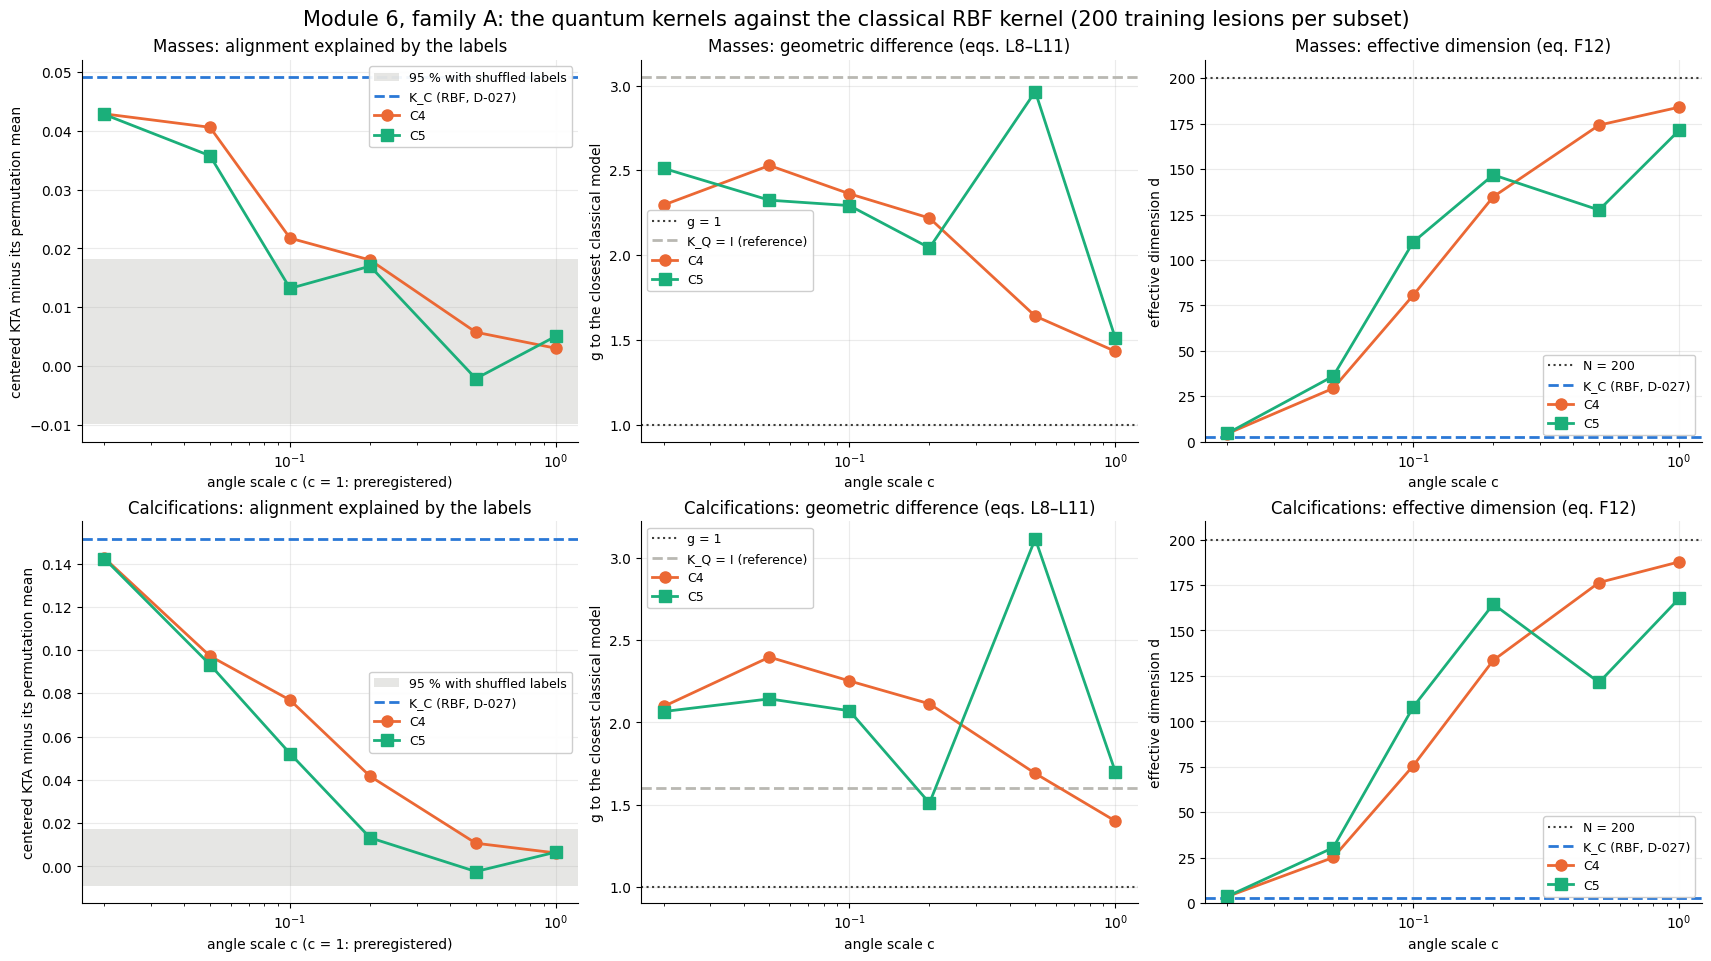

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5), constrained_layout=True)
for row, ft in enumerate(FINDINGS):
    k_ft, g_ft, d_ft = kta[kta.finding_type == ft], gsum[gsum.finding_type == ft], dims[dims.finding_type == ft]
    ax = axes[row, 0]
    ax.axhspan((k_ft.null_p025_centered - k_ft.null_mean_centered).min(), (k_ft.null_p975_centered - k_ft.null_mean_centered).max(),
               color=NULL_GRAY, alpha=0.35, lw=0, label='95 % with shuffled labels')
    ax.axhline(k_ft[k_ft.kernel == 'K_C'].excess_centered.iloc[0], color=COLORS['K_C'], ls='--', label='K_C (RBF, D-027)')
    for q in QUANTUM:
        s = k_ft[k_ft.kernel == q].sort_values('c')
        ax.plot(s.c, s.excess_centered, marker=MARKERS[q], color=COLORS[q], label=q)
    ax.set(xscale='log', xlabel='angle scale c (c = 1: preregistered)', ylabel='centered KTA minus its permutation mean',
           title=f'{TITLES[ft]}: alignment explained by the labels')
    ax = axes[row, 1]
    ax.axhline(1, color=INK, ls=':', lw=1.5, label='g = 1')
    ax.axhline(g_ft[g_ft['map'] == 'identity'].g_min.iloc[0], color=NULL_GRAY, ls='--', label='K_Q = I (reference)')
    for q in QUANTUM:
        s = g_ft[g_ft['map'] == q].sort_values('c')
        ax.plot(s.c, s.g_min, marker=MARKERS[q], color=COLORS[q], label=q)
    ax.set(xscale='log', ylim=(0.9, None), xlabel='angle scale c', ylabel='g to the closest classical model',
           title=f'{TITLES[ft]}: geometric difference (eqs. L8–L11)')
    ax = axes[row, 2]
    ax.axhline(200, color=INK, ls=':', lw=1.5, label='N = 200')
    ax.axhline(d_ft[d_ft.kernel == 'K_C'].effective_dimension.iloc[0], color=COLORS['K_C'], ls='--', label='K_C (RBF, D-027)')
    for q in QUANTUM:
        s = d_ft[d_ft.kernel == q].sort_values('c')
        ax.plot(s.c, s.effective_dimension, marker=MARKERS[q], color=COLORS[q], label=q)
    ax.set(xscale='log', ylim=(0, 210), xlabel='angle scale c', ylabel='effective dimension d',
           title=f'{TITLES[ft]}: effective dimension (eq. F12)')
    for ax in axes[row]:
        ax.legend(fontsize=9, framealpha=0.95)
fig.suptitle('Module 6, family A: the quantum kernels against the classical RBF kernel (200 training lesions per subset)', fontsize=15)
fig.savefig(FIG_DIR / 'M6_kernel_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

**f.** Figure: the geometric difference at $c=1$ against the width of the Gaussian classical kernel, at the largest admissible $\lambda$ of each kernel. Filled markers are the paper's grid and hollow markers the extended widths. A missing point means that no $\lambda$ satisfies $g_{\text{tra}}<0.045$: that classical kernel cannot imitate the quantum one without a large training error.

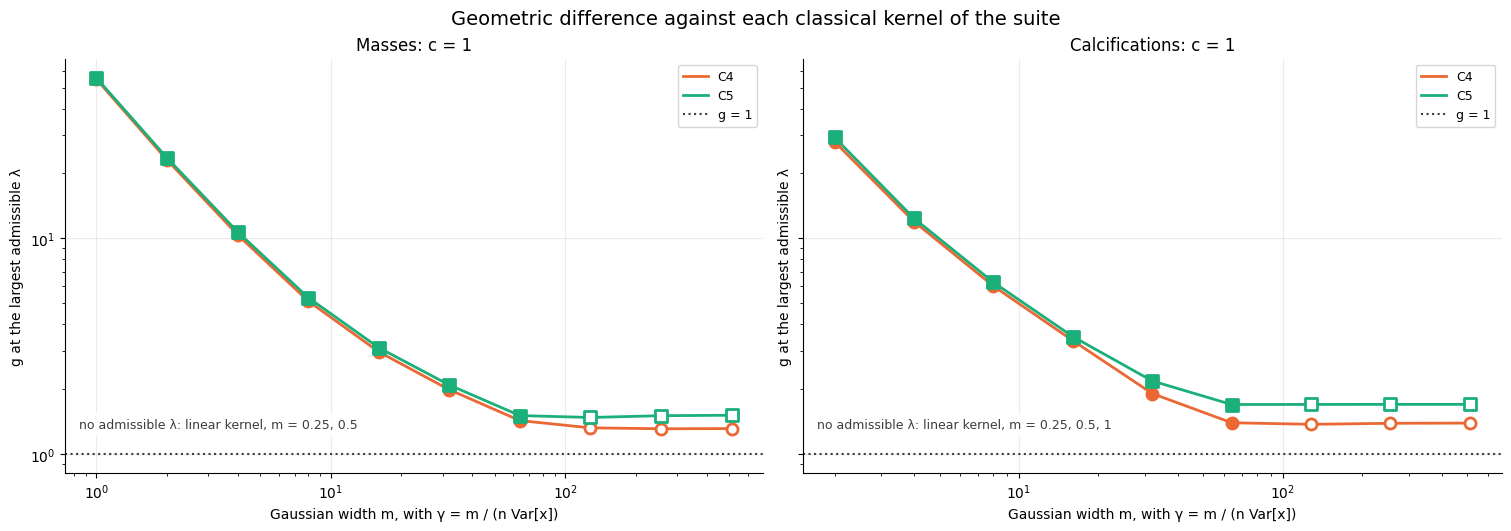

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True, sharey=True)
for ax, ft in zip(axes, FINDINGS):
    part = gdf[(gdf.finding_type == ft) & (gdf.c == 1.0) & gdf.grid.isin(['paper', 'extended'])
               & (gdf.classical_kernel != 'linear') & gdf.admissible]
    best = part.sort_values('lam').groupby(['map', 'classical_kernel']).tail(1)
    best = best.assign(m=best.classical_kernel.str.split().str[1].astype(float))
    for q in QUANTUM:
        s = best[best['map'] == q].sort_values('m')
        ax.plot(s.m, s.g_gen, color=COLORS[q], label=q)
        for grid, face in [('paper', COLORS[q]), ('extended', 'white')]:
            p = s[s.grid == grid]
            ax.scatter(p.m, p.g_gen, marker=MARKERS[q], s=64, facecolor=face, edgecolor=COLORS[q], linewidth=2, zorder=3)
    ax.axhline(1, color=INK, ls=':', lw=1.5, label='g = 1')
    missing = sorted(set(MULTIPLIERS) - set(best.m))
    ax.text(0.02, 0.10, 'no admissible λ: linear kernel' + (', m = ' + ', '.join(f'{m:g}' for m in missing) if missing else ''),
            transform=ax.transAxes, va='bottom', fontsize=9, color=INK, bbox=dict(facecolor='white', edgecolor='none', alpha=0.9))
    ax.set(xscale='log', yscale='log', xlabel='Gaussian width m, with γ = m / (n Var[x])',
           ylabel='g at the largest admissible λ', title=f'{TITLES[ft]}: c = 1')
    ax.legend(fontsize=9, loc='upper right')
fig.suptitle('Geometric difference against each classical kernel of the suite', fontsize=14)
fig.savefig(FIG_DIR / 'M6_geometric_difference.png', dpi=180, bbox_inches='tight')
plt.show()

#### **4° Family B: embedding metrics**

**a.** Davies-Bouldin index, Fisher ratio and linear alignment of the five conditions, on the 200-lesion subsample and, as a robustness check, on the full training split. Every statistic carries its permutation null.

In [11]:
emb_rows = []
for ft in FINDINGS:
    d = data[ft]
    for sample, labels, embs in [('subsample', d['y01'], d['emb']), ('full train', d['y01_train'], d['emb_train'])]:
        p01 = perms01[ft] if sample == 'subsample' else label_permutations(labels, N_PERM, SEED)
        for cond in CONDITIONS:
            e = embs[cond]
            db, db_null = davies_bouldin_score(e, labels), np.array([davies_bouldin_score(e, p) for p in p01])
            fj, fj_null = fisher_ratio(e, labels), np.array([fisher_ratio(e, p) for p in p01])
            la, la_null = linear_alignment(e, 2 * labels - 1)[0], linear_alignment(e, 2 * p01 - 1)
            emb_rows.append({'finding_type': ft, 'sample': sample, 'n': len(labels), 'condition': cond,
                             'davies_bouldin': db, 'db_null_p025': np.percentile(db_null, 2.5),
                             'db_null_p975': np.percentile(db_null, 97.5), 'p_db': (1 + np.sum(db_null <= db)) / (1 + N_PERM),
                             'fisher_j': fj, 'fj_null_p025': np.percentile(fj_null, 2.5),
                             'fj_null_p975': np.percentile(fj_null, 97.5), 'p_fisher': (1 + np.sum(fj_null >= fj)) / (1 + N_PERM),
                             'kta_linear': la, 'la_null_mean': la_null.mean(), 'la_null_p025': np.percentile(la_null, 2.5),
                             'la_null_p975': np.percentile(la_null, 97.5), 'p_kta_linear': (1 + np.sum(la_null >= la)) / (1 + N_PERM)})
embm = pd.DataFrame(emb_rows)
embm.to_csv(RESULTS_DIR / '6_metricas_embedding.csv', index=False)
display(embm[['finding_type', 'sample', 'condition', 'davies_bouldin', 'p_db', 'fisher_j', 'p_fisher', 'kta_linear', 'p_kta_linear']].round(4))

,finding_type,sample,condition,davies_bouldin,p_db,fisher_j,p_fisher,kta_linear,p_kta_linear
0,mass,subsample,C1,4.3010,0.0010,0.6692,0.0040,0.0702,0.0010
1,mass,subsample,C2,4.3010,0.0010,0.6692,0.0040,0.0702,0.0010
2,mass,subsample,C3,5.5641,0.0010,0.7807,0.0020,0.0588,0.0010
3,mass,subsample,C4,5.8985,0.0020,0.4494,0.0500,0.0409,0.0010
4,mass,subsample,C5,13.3457,0.4086,0.6678,0.0030,0.0119,0.4056
5,mass,full train,C1,4.6262,0.0010,0.4540,0.0010,0.0617,0.0010
6,mass,full train,C2,4.6262,0.0010,0.4540,0.0010,0.0617,0.0010
7,mass,full train,C3,5.7307,0.0010,0.4407,0.0010,0.0561,0.0010
8,mass,full train,C4,10.3235,0.0010,0.1283,0.0010,0.0152,0.0010
9,mass,full train,C5,16.8565,0.0010,0.2115,0.0010,0.0075,0.0010


**b.** Figure: the three embedding metrics on the subsample. Each gray whisker is the central 95 % of the metric with shuffled labels for that condition: a bar inside its whisker cannot be told apart from chance. For Davies-Bouldin lower is more separated; for the other two, higher.

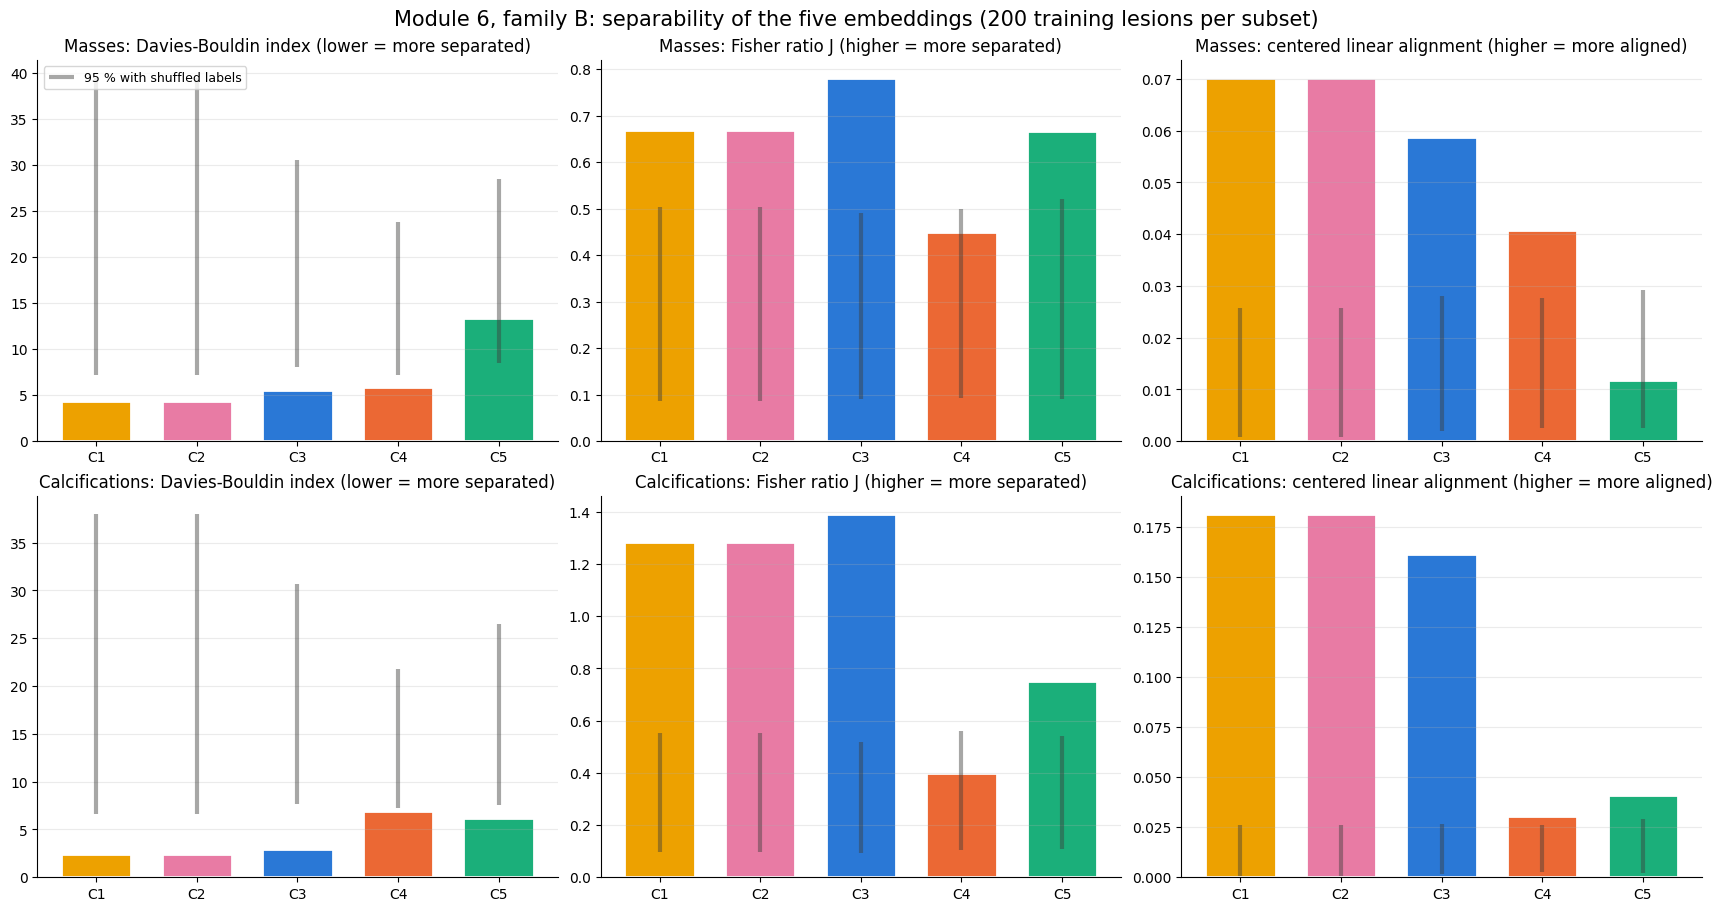

In [12]:
metrics = [('davies_bouldin', 'db', 'Davies-Bouldin index (lower = more separated)'),
           ('fisher_j', 'fj', 'Fisher ratio J (higher = more separated)'),
           ('kta_linear', 'la', 'centered linear alignment (higher = more aligned)')]
fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
pos = np.arange(len(CONDITIONS))
for row, ft in enumerate(FINDINGS):
    part = embm[(embm.finding_type == ft) & (embm['sample'] == 'subsample')].set_index('condition').loc[CONDITIONS]
    for col, (metric, null, label) in enumerate(metrics):
        ax = axes[row, col]
        ax.bar(pos, part[metric], width=0.7, color=[COLORS[c] for c in CONDITIONS], edgecolor='white', linewidth=2)
        ax.vlines(pos, part[f'{null}_null_p025'], part[f'{null}_null_p975'], color=INK, lw=3, alpha=0.45,
                  label='95 % with shuffled labels')
        ax.set_xticks(pos, CONDITIONS)
        ax.set(title=f'{TITLES[ft]}: {label}')
        ax.grid(axis='x', visible=False)
        if col == 0 and row == 0:
            ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Module 6, family B: separability of the five embeddings (200 training lesions per subset)', fontsize=15)
fig.savefig(FIG_DIR / 'M6_embedding_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

**c.** t-SNE projections of the five embeddings. t-SNE preserves neighbourhoods, not distances or densities, so it is a visual aid and never a metric. All projections use perplexity 30, PCA initialization and seed 42. C1 and C2 have the same pairwise distances, and their projections can differ only by a reflection.

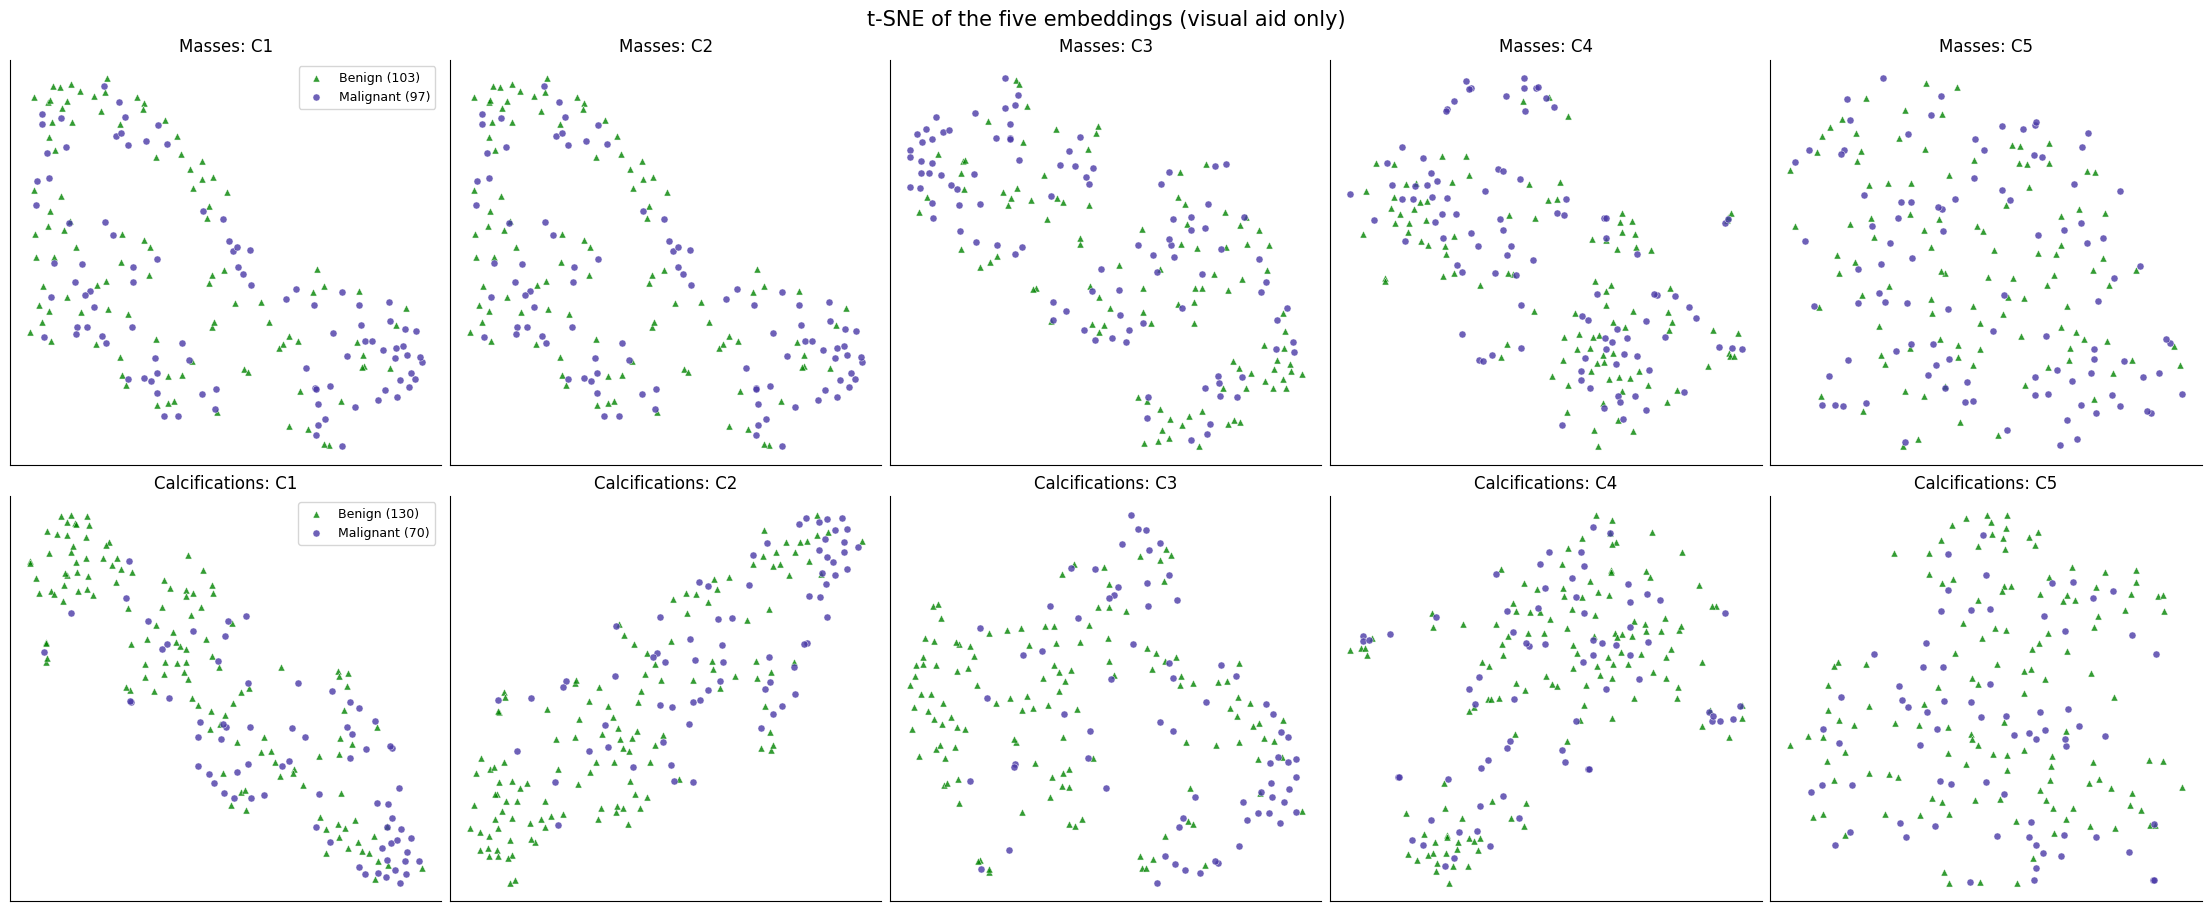

t-SNE computed for 10 embeddings


In [13]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), constrained_layout=True)
for row, ft in enumerate(FINDINGS):
    y01 = data[ft]['y01']
    for col, cond in enumerate(CONDITIONS):
        proj = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=SEED).fit_transform(data[ft]['emb'][cond])
        ax = axes[row, col]
        for cls, (name, color, marker) in CLASS_STYLE.items():
            ax.scatter(*proj[y01 == cls].T, s=26, marker=marker, color=color, alpha=0.8, edgecolor='white', linewidth=0.4,
                       label=f'{name} ({int((y01 == cls).sum())})')
        ax.set(title=f'{TITLES[ft]}: {cond}', xticks=[], yticks=[])
        ax.grid(False)
        if col == 0:
            ax.legend(fontsize=9, loc='best')
fig.suptitle('t-SNE of the five embeddings (visual aid only)', fontsize=15)
fig.savefig(FIG_DIR / 'M6_tsne.png', dpi=160, bbox_inches='tight')
plt.show()
print('t-SNE computed for', len(FINDINGS) * len(CONDITIONS), 'embeddings')

#### **5° Verifications**

**a.** The null control and the monotonicity of the regularized geometric difference on the real kernels, added to the synthetic checks of 2°c

In [14]:
for (ft, sample), part in embm.groupby(['finding_type', 'sample'], sort=False):
    p = part.set_index('condition')
    diff = max(abs(p.loc['C1', m] - p.loc['C2', m]) for m in ['davies_bouldin', 'fisher_j', 'kta_linear'])
    check(f'{ft}, {sample}: C1 and C2 give the same embedding metrics (D-016)', diff, diff < 1e-8)
steps = (gdf[gdf.lam > 0].sort_values('lam')
         .groupby(['finding_type', 'map', 'c', 'classical_kernel'], dropna=False).g_gen
         .apply(lambda s: np.diff(s.to_numpy()).max()))
check('real kernels: g_gen does not increase with lambda', steps.max(), steps.max() <= 1e-9)
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / '6_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,psd_sqrt reconstructs K,7.482903e-14,True
1,g(K || K) = 1 without regularization,1.032507e-13,True
2,g against the identity = 1 / sqrt(lambda_min(K...,3.552714e-15,True
3,g_gen does not increase with lambda,-6.740307e-03,True
4,alignment of yy^T with itself = 1,3.330669e-16,True
5,uncentered alignment of the identity = 1/sqrt(n),2.775558e-17,True
6,centered alignment of the identity = 1/sqrt(n-...,1.665335e-16,True
7,effective dimension of the identity = N,0.000000e+00,True
8,effective dimension of a rank-one kernel = 1,2.353673e-14,True
9,Fisher ratio invariant under an invertible aff...,1.776357e-15,True


Checks passed: 20/20


#### **6° Consequence**

**1. Family A at the preregistered scale: the quantum kernels barely see the classes.**

- **Alignment.** The raw centered alignment would suggest the opposite in masses, 0.073 for C4 against 0.059 for the RBF, but about 0.071 is the value that any kernel close to the identity takes whatever the labels. The part explained by the labels is what matters. In masses it is 0.049 for the RBF against 0.003 (C4) and 0.005 (C5); in calcifications, 0.152 against 0.006 and 0.007. The quantum kernels keep between 4 % and 10 % of the label-explained alignment of the classical kernel. Their excess is significant ($p\le0.003$) but small, in agreement with the pair AUC of X2 (H-036).
- **Effective dimension.** It is 184 and 188 of 200 for C4 and 171 and 168 for C5, against 2.8 and 2.6 for the RBF. The quantum states of 200 lesions span an almost 200-dimensional space: each lesion looks unrelated to all the others. This is the regime that Huang et al. describe as *"all inputs are too far apart"*. By their eq. (8), the error bound of the quantum kernel method grows with $\sqrt{\min(d,\operatorname{Tr}O^2)/N}$, so with $d\approx N$ it gives no guarantee of generalization.
- **Geometric difference.** The distance to the closest classical model is 1.43 (C4) and 1.51 (C5) in masses and 1.40 and 1.70 in calcifications, all far below $\sqrt{N}=14.1$. In the flowchart of their Fig. 1 that is the case in which classical ML predicts similarly or better for any labels.
  - The closest classical model is the narrowest Gaussian of the grid ($\gamma\approx6.3$–$6.8$, $\lambda=0.01$): a classical kernel that also treats the lesions as almost isolated.
  - The minimum lies at the edge of the paper's grid. The extended widths lower it slightly, to 1.31, 1.48, 1.38 and 1.70, so the conclusion only becomes stronger.
  - The RBF of D-027 admits no $\lambda$ with $g_{\text{tra}}<0.045$ for $c\ge0.05$: a smooth classical kernel cannot imitate the quantum ones without a large training error. Its unregularized $g$, between 306 and 388, is the misleading number discussed in 2°a.

**2. The angle-scaling sweep (D-029).** As $c$ decreases, the label-explained alignment of C4 and C5 rises towards that of the RBF: at $c=0.02$ it is 0.043 against 0.049 in masses and 0.143 against 0.152 in calcifications. The dimension falls to about 4, and $g$ stays between 2.1 and 2.5. At that scale the quantum kernel is practically the kernel of a map without the product term $x_ix_j$ (H-031), so the alignment it recovers is the one a classical kernel already sees. The largest $g$ of the whole sweep is 3.1, for C5 at $c=0.5$, still far below $\sqrt{N}$.

**3. Family B: the quantum embeddings are less separable than the classical ones.**

| Subsample of 200 | C1 = C2 | C3 | C4 | C5 |
|---|---|---|---|---|
| Fisher $J$, masses | 0.67 | 0.78 | 0.45 ($p=0.05$) | 0.67 |
| Fisher $J$, calcifications | 1.28 | 1.39 | 0.40 ($p=0.15$) | 0.75 |
| Davies-Bouldin, masses (lower is better) | 4.30 | 5.56 | 5.90 | 13.35 ($p=0.41$) |
| Davies-Bouldin, calcifications | 2.39 | 2.99 | 6.89 | 6.25 |
| Linear alignment, masses | 0.070 | 0.059 | 0.041 | 0.012 ($p=0.41$) |
| Linear alignment, calcifications | 0.181 | 0.161 | 0.031 | 0.041 |

- On the full training split (1,318 masses and 1,546 calcifications) every metric is significant and the ordering is the same. The Fisher ratio is 0.45, 0.44, 0.13 and 0.21 for C1, C3, C4 and C5 in masses, and 1.06, 1.00, 0.42 and 0.31 in calcifications.
- C4 against C5 has no consistent winner. C5 is ahead in the Fisher ratio on the subsample and in masses on the full split, and behind in calcifications on the full split and in the Davies-Bouldin index of masses. The Y term changes the embedding (H-037) without making it consistently more separable.
- C1 and C2 coincide to $10^{-14}$ in every metric (D-016): the instruments do not react to a rotation.

**4. The two families agree in direction, not in detail (H-013, H-037).** Both put the classical representations ahead at $c=1$, in both subsets. Their details differ. C5 has smaller typical overlaps than C4 (H-037) but a lower effective dimension (171 against 184 in masses), consistent with the wider distribution of its kernel values in 5b: a few larger overlaps concentrate its spectrum. In family B, C5 is not consistently ahead of or behind C4.

**5. What this answers (OE-3).** With the preregistered design, the quantum transformations do not give benign and malignant lesions a greater separability than the classical transformations, in either family of metrics or subset. Under the framework of the project this is a viability result, not a failure. The 12-qubit encoding places the lesions in the regime that Huang et al. identify as the typical cause of no quantum advantage, and only an angle scale at which the feature interactions disappear brings its separability back to the classical level.

The limits of this answer:
- 200 lesions per subset;
- $p$ values that are indicative, because many statistics are tested;
- a geometric difference that depends on the classical suite;
- $k=12$, chosen by cost. H-018 asks to compare against $k=8$ before concluding that the quantum encoding contributes nothing.

In [15]:
print('=' * 84)
print('MODULE 6 - SEPARABILITY - SUMMARY (200 training lesions per subset, c = 1 unless stated)')
print('=' * 84)
for ft in FINDINGS:
    k = kta[(kta.finding_type == ft) & (kta.c.isna() | (kta.c == 1.0))].set_index('kernel')
    g = gsum[(gsum.finding_type == ft) & (gsum.c.isna() | (gsum.c == 1.0))].set_index('map')
    dd = dims[(dims.finding_type == ft) & (dims.c.isna() | (dims.c == 1.0))].set_index('kernel')
    e = embm[(embm.finding_type == ft) & (embm['sample'] == 'subsample')].set_index('condition')
    print(f'  {TITLES[ft]}')
    print(f"    centered KTA   K_C {k.loc['K_C', 'kta_centered']:.3f} (p {k.loc['K_C', 'p_centered']:.3f}) | "
          + ' | '.join(f"{q} {k.loc[q, 'kta_centered']:.3f} (p {k.loc[q, 'p_centered']:.3f})" for q in QUANTUM))
    print(f"    KTA excess     K_C {k.loc['K_C', 'excess_centered']:.4f} | "
          + ' | '.join(f"{q} {k.loc[q, 'excess_centered']:.4f}" for q in QUANTUM) + '  (centered KTA minus its permutation mean)')
    print(f"    min g          " + ' | '.join(f"{q} {g.loc[q, 'g_min']:.2f} ({g.loc[q, 'kernel_at_min']}, λ {g.loc[q, 'lambda_at_min']:g})" for q in QUANTUM)
          + f" | K_Q = I {g.loc['identity', 'g_min']:.2f} | sqrt(N) = {np.sqrt(len(data[ft]['y'])):.1f}")
    print(f"    g without λ    vs D-027 RBF: " + ' | '.join(f"{q} {g.loc[q, 'd027_g_unregularized']:.0f}" for q in QUANTUM))
    print(f"    dimension d    K_C {dd.loc['K_C', 'effective_dimension']:.1f} | "
          + ' | '.join(f"{q} {dd.loc[q, 'effective_dimension']:.1f}" for q in QUANTUM) + ' (of 200)')
    print('    Fisher J       ' + ' | '.join(f"{c} {e.loc[c, 'fisher_j']:.3f}" for c in CONDITIONS))
    print('    Davies-Bouldin ' + ' | '.join(f"{c} {e.loc[c, 'davies_bouldin']:.2f}" for c in CONDITIONS))
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 84)

MODULE 6 - SEPARABILITY - SUMMARY (200 training lesions per subset, c = 1 unless stated)
  Masses
    centered KTA   K_C 0.059 (p 0.001) | C4 0.073 (p 0.002) | C5 0.075 (p 0.003)
    KTA excess     K_C 0.0491 | C4 0.0030 | C5 0.0051  (centered KTA minus its permutation mean)
    min g          C4 1.43 (gaussian 64, λ 0.01) | C5 1.51 (gaussian 64, λ 0.01) | K_Q = I 3.05 | sqrt(N) = 14.1
    g without λ    vs D-027 RBF: C4 306 | C5 309
    dimension d    K_C 2.8 | C4 184.0 | C5 171.3 (of 200)
    Fisher J       C1 0.669 | C2 0.669 | C3 0.781 | C4 0.449 | C5 0.668
    Davies-Bouldin C1 4.30 | C2 4.30 | C3 5.56 | C4 5.90 | C5 13.35
  Calcifications
    centered KTA   K_C 0.161 (p 0.001) | C4 0.077 (p 0.001) | C5 0.075 (p 0.003)
    KTA excess     K_C 0.1515 | C4 0.0062 | C5 0.0066  (centered KTA minus its permutation mean)
    min g          C4 1.40 (gaussian 64, λ 0.01) | C5 1.70 (gaussian 64, λ 0.01) | K_Q = I 1.60 | sqrt(N) = 14.1
    g without λ    vs D-027 RBF: C4 376 | C5 388
    dim